## ===================================================
## 💰 Hopify Top 10 Products by Revenue – Horizontal Barplot
## ===================================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

## ================================
## 📁 Set Base Path to Project Root
## ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ==================================================
## 📥 Load Data
## ==================================================

In [2]:
# Define file path and load data
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "03_project_product_cust_behavior_insights",
    "02_hopify_top_prod_cat_rev_seg.csv"
)

df = pd.read_csv(file_path)

# ================================
# 🧼 Clean & Sort Columns
# ================================

In [3]:
# Clean up column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Ensure numeric revenue
df["total_revenue"] = pd.to_numeric(df["total_revenue"], errors="coerce")

# Sort ascending for horizontal bars
df = df.sort_values("total_revenue", ascending=True)

# ================================
# 📊 Plot
# ================================

/var/folders/z4/bhxvrvmn0n30jr8zdx9wy1x80000gn/T/ipykernel_16794/4146178816.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


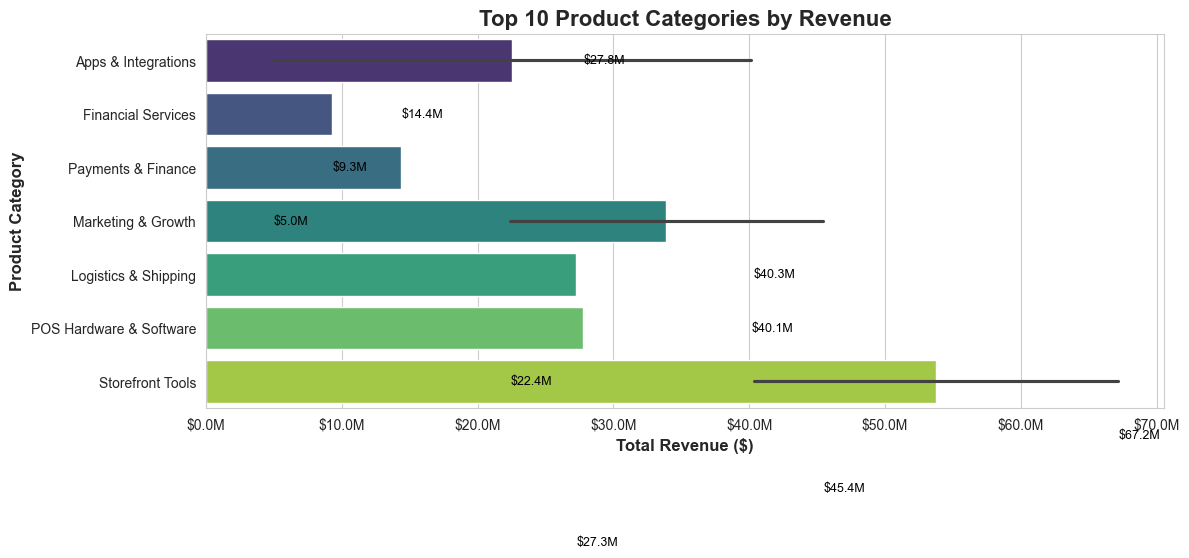

In [4]:

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df,
    x="total_revenue",
    y="category",  # ✅ corrected from category_name
    palette="viridis"
)

# Format x-axis as dollars
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

# Add labels at end of bars
for i, row in df.iterrows():
    if pd.notna(row["total_revenue"]):
        ax.text(
            row["total_revenue"] + 25000, i,
            f"${row['total_revenue'] / 1e6:.1f}M",
            color='black', fontsize=9, va='center'
        )

plt.title("Top 10 Product Categories by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Total Revenue ($)", fontsize=12, fontweight="bold")
plt.ylabel("Product Category", fontsize=12, fontweight="bold")
plt.tight_layout()

## ================================
## 💾 Save & Show
## ================================

In [5]:
output_path = os.path.join(
    BASE_PATH,
    "05_visuals",
    "03_project_product_cust_behavior_insights",
    "hopify_top_10_product_categories.png"
)
plt.savefig(output_path, dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>